# Minimal policy gradients with an LLM

This notebook is a small, runnable version of the policy-gradient part of the tutorial, **Intelligence via generation and selection**.

We use the same identification as the TeX note:

- observation $o$: a prompt or context;
- action $a$: the LLM completion;
- policy $\pi(a\mid o;\theta)$: an autoregressive language model;
- reward $r(a,o)$: an evaluator, verifier, unit test, or reward-model score.

To keep the mechanics visible, the “LLM” below is a tiny word-level causal language model trained from scratch. It generates **one answer token** after a prompt. A real LLM version uses the same estimator, except $\log \pi(a\mid o)$ is the **sum of log-probabilities of all generated tokens**.


## The one-step objective

The tutorial writes the one-step LLM-RL objective as

$$
J(\theta)=\mathbb{E}_{o\sim P(o),\;a\sim\pi(\cdot\mid o;\theta)}[r(a,o)].
$$

Using the log-derivative trick,

$$
\nabla_\theta J(\theta)
=\mathbb{E}\left[r(a,o)\nabla_\theta\log \pi(a\mid o;\theta)\right].
$$

With a mini-batch, we use the Monte Carlo estimate

$$
\nabla_\theta J(\theta)\approx \frac{1}{N}\sum_{i=1}^{N} A_i\nabla_\theta\log \pi(a_i\mid o_i;\theta).
$$

The code below uses a frozen SFT/reference model $\pi_{\mathrm{ref}}$ and a sampled KL penalty,

$$
\tilde r_i
= r_i - \beta\left(\log\pi(a_i\mid o_i;\theta)-\log\pi_{\mathrm{ref}}(a_i\mid o_i)\right).
$$

Then it forms a standardized advantage from the shaped rewards,

$$
A_i = \frac{\tilde r_i - \operatorname{mean}(\tilde r)}{\operatorname{std}(\tilde r)+\epsilon},
$$

and minimizes the policy-gradient loss

$$
\mathcal{L}_{\mathrm{PG}}(\theta)
=-\frac{1}{N}\sum_i A_i\log \pi(a_i\mid o_i;\theta).
$$


In [1]:
import os
import random
from dataclasses import dataclass

# Matplotlib may otherwise try to write its cache under the home directory.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# This keeps the demo fast and predictable on small CPU-only machines.
torch.set_num_threads(1)

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

# Device preference: CUDA if available, then Apple Silicon MPS, then CPU.
# Set USE_MPS = False if your local PyTorch build hits an unsupported MPS op.
USE_MPS = True
mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
mps_built = hasattr(torch.backends, "mps") and torch.backends.mps.is_built()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif USE_MPS and mps_available:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("mps built:", mps_built, "| mps available:", mps_available)


device: mps
mps built: True | mps available: True


## A tiny prompt-completion environment

The environment is a small set of prompts. The model must generate the correct one-token answer.

This is deliberately simple: it lets us see the RL loop without needing an external model download, a reward model, or a dataset.

In [2]:
pairs = [
    ("Question: what animal says meow ? Answer:", "cat"),
    ("Question: what animal says woof ? Answer:", "dog"),
    ("Question: what animal says moo ? Answer:", "cow"),
    ("Question: what animal says oink ? Answer:", "pig"),
    ("Question: what colour is grass ? Answer:", "green"),
    ("Question: what colour is sky ? Answer:", "blue"),
    ("Question: what colour is banana ? Answer:", "yellow"),
    ("Question: what colour is snow ? Answer:", "white"),
]

SPECIAL = ["<pad>"]
vocab = SPECIAL + sorted(set(w for prompt, target in pairs for w in prompt.split() + [target]))
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
pad_id = stoi["<pad>"]

answer_words = {target for _, target in pairs}

def encode(text: str):
    return [stoi[w] for w in text.split()]

encoded_prompts = [encode(prompt) for prompt, _ in pairs]
target_ids = torch.tensor([stoi[target] for _, target in pairs], device=device)

print(f"vocab size: {len(vocab)}")
print(vocab)


vocab size: 25
['<pad>', '?', 'Answer:', 'Question:', 'animal', 'banana', 'blue', 'cat', 'colour', 'cow', 'dog', 'grass', 'green', 'is', 'meow', 'moo', 'oink', 'pig', 'says', 'sky', 'snow', 'what', 'white', 'woof', 'yellow']


In [3]:
def make_prompt_batch(indices):
    """Return padded prompt tokens, prompt lengths, and target answer ids."""
    seqs = [encoded_prompts[i] for i in indices]
    lengths = torch.tensor([len(s) for s in seqs], device=device)
    max_len = int(lengths.max().item())

    x = torch.full((len(seqs), max_len), pad_id, dtype=torch.long, device=device)
    for row, seq in enumerate(seqs):
        x[row, : len(seq)] = torch.tensor(seq, dtype=torch.long, device=device)

    targets = target_ids[torch.tensor(indices, device=device)]
    return x, lengths, targets


## Tiny causal language model

The model reads prompt tokens and returns next-token logits at the final prompt position. In a full transformer LLM, this would be the logits for the next generated token after the prompt.

In [4]:
class TinyCausalLM(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 48):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.rnn = nn.GRU(d_model, d_model, batch_first=True)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, lengths):
        """Return next-token logits after each prompt."""
        hidden_states, _ = self.rnn(self.embed(input_ids))
        last_hidden = hidden_states[torch.arange(input_ids.size(0), device=input_ids.device), lengths - 1]
        return self.lm_head(last_hidden)

policy = TinyCausalLM(len(vocab)).to(device)


In [5]:
answer_vocab = sorted(answer_words)
answer_ids = torch.tensor([stoi[word] for word in answer_vocab], device=device)
prompt_labels = [prompt.replace("Question: what ", "").replace(" ? Answer:", "") for prompt, _ in pairs]


@torch.no_grad()
def policy_answer_probs(model):
    """Return P(answer word | prompt) for the answer vocabulary only."""
    x, lengths, _ = make_prompt_batch(list(range(len(pairs))))
    probs = torch.softmax(model(x, lengths), dim=-1)
    return probs[:, answer_ids].cpu()


@torch.no_grad()
def evaluate(model):
    """Greedy accuracy and exact expected sampled accuracy under the current policy."""
    x, lengths, targets = make_prompt_batch(list(range(len(pairs))))
    logits = model(x, lengths)
    probs = torch.softmax(logits, dim=-1)
    greedy = logits.argmax(dim=-1)
    greedy_acc = (greedy == targets).float().mean().item()

    # For this one-token environment, expected sampled accuracy is exactly P(target).
    target_probs = probs.gather(1, targets[:, None]).squeeze(1)
    sample_acc = target_probs.mean().item()

    greedy_words = [itos[int(a)] for a in greedy]
    return {
        "greedy_acc": greedy_acc,
        "sample_acc": sample_acc,
        "greedy_words": greedy_words,
    }


initial_eval = evaluate(policy)
initial_probs = policy_answer_probs(policy)
print("initial:", initial_eval)


initial: {'greedy_acc': 0.125, 'sample_acc': 0.04286297410726547, 'greedy_words': ['cow', 'cow', 'cow', 'cow', 'cow', 'snow', 'cow', 'cow']}


## Step 1: SFT warm-start

The tutorial distinguishes SFT from RL:

$$
\max_\theta\;\mathbb{E}_{(o,a)\sim\mathcal{D}}[\log\pi(a\mid o;\theta)].
$$

Here we do a deliberately short SFT warm-start so the policy is not random, then freeze a copy as $\pi_{\mathrm{ref}}$. The RL step will improve the policy by sampling its own answers and weighting them by reward.


In [6]:
def sft_step(model, opt, batch_size: int = 8):
    indices = torch.randint(0, len(pairs), (batch_size,)).tolist()
    x, lengths, targets = make_prompt_batch(indices)
    logits = model(x, lengths)
    loss = F.cross_entropy(logits, targets)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    return float(loss.item())


sft_opt = torch.optim.Adam(policy.parameters(), lr=3e-3)
sft_losses = []

# A short warm-start makes exploration feasible while leaving room for RL to improve.
for step in range(35):
    sft_losses.append(sft_step(policy, sft_opt))

sft_eval = evaluate(policy)
sft_probs = policy_answer_probs(policy)
print("after short SFT:", sft_eval)

# Freeze the SFT policy as a KL/reference model.
ref_policy = TinyCausalLM(len(vocab)).to(device)
ref_policy.load_state_dict(policy.state_dict())
ref_policy.eval()
for p in ref_policy.parameters():
    p.requires_grad_(False)


after short SFT: {'greedy_acc': 0.875, 'sample_acc': 0.39882463216781616, 'greedy_words': ['cat', 'dog', 'dog', 'pig', 'green', 'blue', 'yellow', 'white']}


## Step 2: Policy-gradient rollouts

Each RL iteration does the tutorial’s loop:

$$
\text{generate}\rightarrow\text{score/select}\rightarrow\text{learn}\rightarrow\text{repeat}.
$$

For a mini-batch of prompts:

1. sample actions $a_i\sim\pi(\cdot\mid o_i;\theta)$,
2. score each action with reward $r_i=1$ if it is correct, otherwise $0$,
3. compute a KL-shaped reward $\tilde r_i$,
4. standardize $\tilde r_i$ inside the batch to get advantages $A_i$,
5. minimize $-A_i\log\pi(a_i\mid o_i;\theta)$.


In [7]:
@dataclass
class PGStats:
    loss: float
    reward: float
    shaped_reward: float
    kl: float
    entropy: float
    greedy_acc: float
    sample_acc: float


def policy_gradient_step(model, ref_model, opt, batch_size: int = 64, beta: float = 0.02):
    # 1. Sample observations/prompts from P(o).
    indices = torch.randint(0, len(pairs), (batch_size,)).tolist()
    x, lengths, targets = make_prompt_batch(indices)

    # 2. Current policy distribution pi(a | o; theta).
    logits = model(x, lengths)
    dist = torch.distributions.Categorical(logits=logits)
    actions = dist.sample()
    logp = dist.log_prob(actions)
    entropy = dist.entropy().mean()

    # 3. Frozen reference log-probabilities pi_ref(a | o).
    with torch.no_grad():
        ref_logits = ref_model(x, lengths)
        ref_dist = torch.distributions.Categorical(logits=ref_logits)
        ref_logp = ref_dist.log_prob(actions)

        # 4. Reward from the evaluator/verifier.
        reward = (actions == targets).float()

        # 5. Sampled KL penalty and standardized advantage.
        sampled_kl = logp - ref_logp
        shaped_reward = reward - beta * sampled_kl
        advantage = (shaped_reward - shaped_reward.mean()) / (shaped_reward.std() + 1e-8)

    # 6. REINFORCE loss: gradient of -A log pi is -A grad log pi.
    loss = -(advantage * logp).mean()

    opt.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()

    eval_stats = evaluate(model)
    return PGStats(
        loss=float(loss.item()),
        reward=float(reward.mean().item()),
        shaped_reward=float(shaped_reward.mean().item()),
        kl=float(sampled_kl.mean().item()),
        entropy=float(entropy.item()),
        greedy_acc=eval_stats["greedy_acc"],
        sample_acc=eval_stats["sample_acc"],
    )


In [8]:
rl_opt = torch.optim.Adam(policy.parameters(), lr=1e-3)

history = []
for step in range(201):
    stats = policy_gradient_step(policy, ref_policy, rl_opt, batch_size=64, beta=0.02)
    history.append(stats)
    if step % 50 == 0:
        print(
            f"step {step:03d} | "
            f"batch reward {stats.reward:.3f} | "
            f"expected sample acc {stats.sample_acc:.3f} | "
            f"greedy acc {stats.greedy_acc:.3f} | "
            f"sampled KL {stats.kl:.3f}"
        )

final_eval = evaluate(policy)
final_probs = policy_answer_probs(policy)
print("final:", final_eval)


step 000 | batch reward 0.406 | expected sample acc 0.407 | greedy acc 1.000 | sampled KL 0.000
step 050 | batch reward 0.750 | expected sample acc 0.851 | greedy acc 1.000 | sampled KL 0.372
step 100 | batch reward 0.938 | expected sample acc 0.961 | greedy acc 1.000 | sampled KL 0.673
step 150 | batch reward 0.969 | expected sample acc 0.981 | greedy acc 1.000 | sampled KL 0.805
step 200 | batch reward 1.000 | expected sample acc 0.990 | greedy acc 1.000 | sampled KL 0.919
final: {'greedy_acc': 1.0, 'sample_acc': 0.989526629447937, 'greedy_words': ['cat', 'dog', 'cow', 'pig', 'green', 'blue', 'yellow', 'white']}


## Plot the learning dynamics

The first plot shows the generate-score-learn loop improving expected sampled accuracy and greedy accuracy. The second plot shows the tradeoff introduced by the reference-policy KL penalty: the policy gets better while gradually moving away from the SFT model.


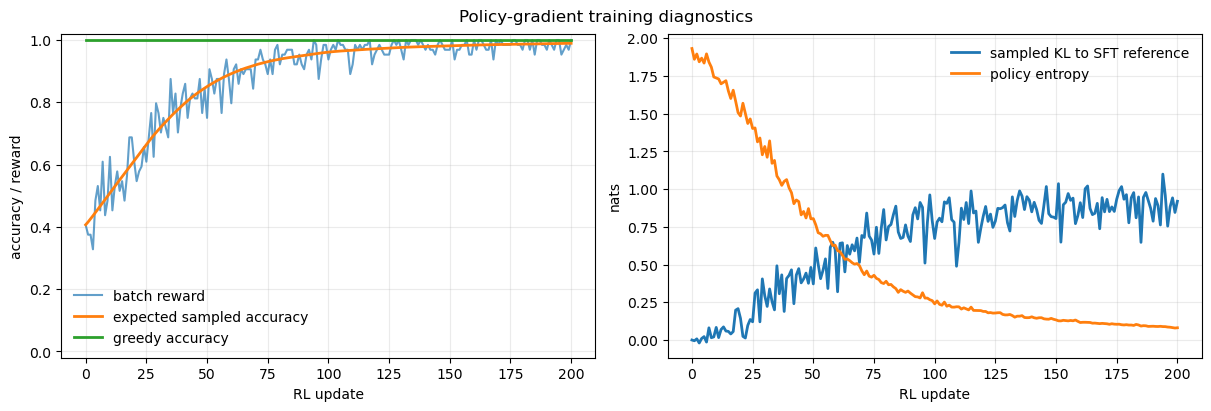

In [9]:
def plot_training_history(history):
    steps = list(range(len(history)))
    batch_reward = [h.reward for h in history]
    sample_acc = [h.sample_acc for h in history]
    greedy_acc = [h.greedy_acc for h in history]
    sampled_kl = [h.kl for h in history]
    entropy = [h.entropy for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(steps, batch_reward, label="batch reward", alpha=0.7)
    axes[0].plot(steps, sample_acc, label="expected sampled accuracy", linewidth=2)
    axes[0].plot(steps, greedy_acc, label="greedy accuracy", linewidth=2)
    axes[0].set_xlabel("RL update")
    axes[0].set_ylabel("accuracy / reward")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].plot(steps, sampled_kl, label="sampled KL to SFT reference", linewidth=2)
    axes[1].plot(steps, entropy, label="policy entropy", linewidth=2)
    axes[1].set_xlabel("RL update")
    axes[1].set_ylabel("nats")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(frameon=False)

    fig.suptitle("Policy-gradient training diagnostics")
    plt.show()


plot_training_history(history)


## Plot what the policy learned

These heatmaps show the probability assigned to each possible answer word for every prompt. The SFT/reference policy is still uncertain; after RL, probability mass concentrates on the rewarded answers.


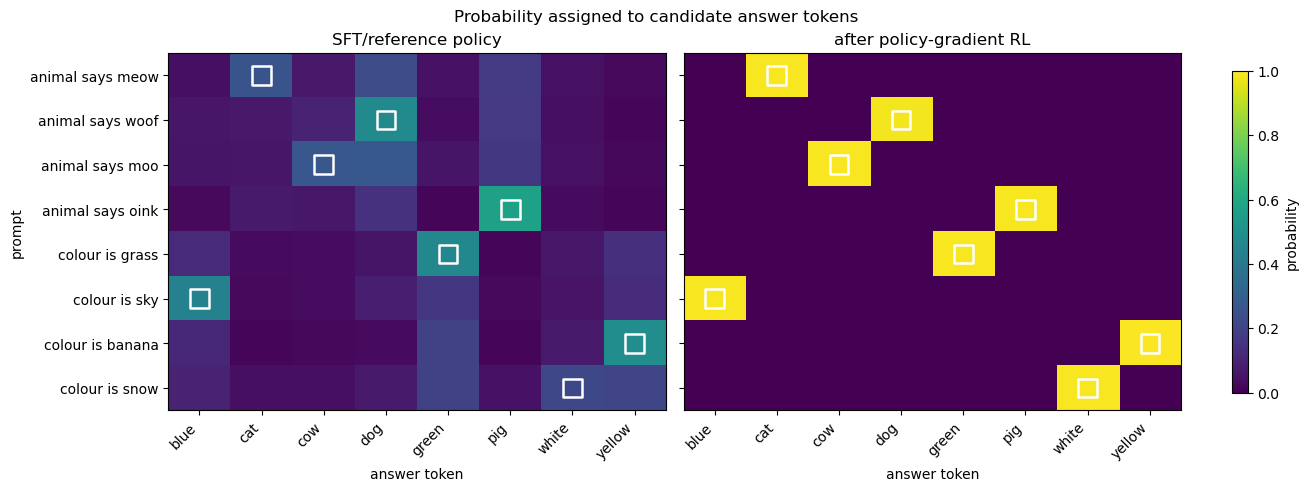

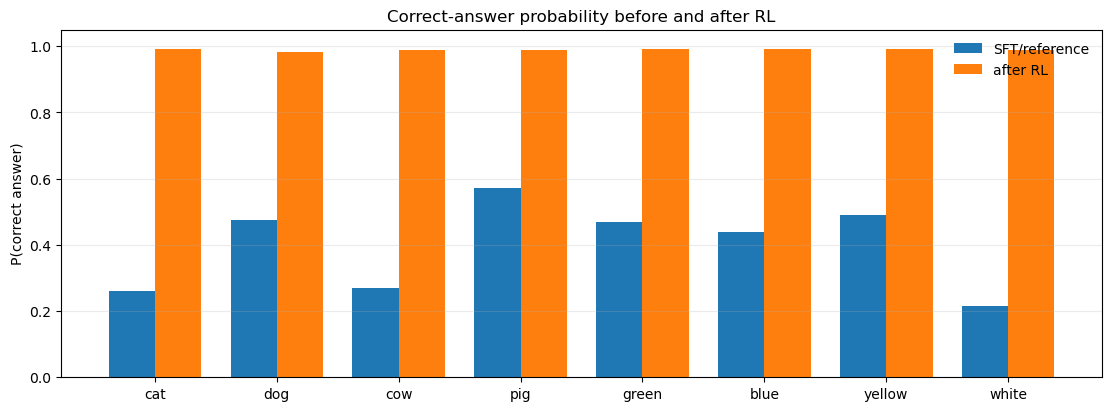

In [10]:
def plot_answer_probability_heatmaps(before, after):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True, sharey=True)
    panels = [(before, "SFT/reference policy"), (after, "after policy-gradient RL")]

    for ax, (matrix, title) in zip(axes, panels):
        im = ax.imshow(matrix.numpy(), aspect="auto", vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(title)
        ax.set_xticks(range(len(answer_vocab)))
        ax.set_xticklabels(answer_vocab, rotation=45, ha="right")
        ax.set_yticks(range(len(prompt_labels)))
        ax.set_yticklabels(prompt_labels)
        ax.set_xlabel("answer token")

        for row, (_, target) in enumerate(pairs):
            col = answer_vocab.index(target)
            ax.scatter(col, row, marker="s", s=180, facecolors="none", edgecolors="white", linewidths=1.8)

    axes[0].set_ylabel("prompt")
    fig.colorbar(im, ax=axes, shrink=0.9, label="probability")
    fig.suptitle("Probability assigned to candidate answer tokens")
    plt.show()


def plot_target_probability_change(before, after):
    before_target = []
    after_target = []
    for row, (_, target) in enumerate(pairs):
        col = answer_vocab.index(target)
        before_target.append(float(before[row, col]))
        after_target.append(float(after[row, col]))

    x = range(len(pairs))
    width = 0.38
    fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
    ax.bar([i - width / 2 for i in x], before_target, width=width, label="SFT/reference")
    ax.bar([i + width / 2 for i in x], after_target, width=width, label="after RL")
    ax.set_xticks(list(x))
    ax.set_xticklabels([target for _, target in pairs], rotation=0)
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("P(correct answer)")
    ax.set_title("Correct-answer probability before and after RL")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)
    plt.show()


plot_answer_probability_heatmaps(sft_probs, final_probs)
plot_target_probability_change(sft_probs, final_probs)


## Inspect the learned policy

The greedy answer is the highest-probability token after each prompt. The sampled probabilities show whether RL made the correct answer likely, not merely greedily preferred.

In [11]:
@torch.no_grad()
def show_policy_table(model):
    x, lengths, targets = make_prompt_batch(list(range(len(pairs))))
    probs = torch.softmax(model(x, lengths), dim=-1)

    rows = []
    for i, (prompt, target) in enumerate(pairs):
        top_probs, top_ids = probs[i].topk(3)
        target_prob = probs[i, stoi[target]].item()
        rows.append({
            "prompt": prompt,
            "target": target,
            "greedy_answer": itos[int(top_ids[0].item())],
            "P(target)": round(target_prob, 3),
            "top_3": ", ".join(
                f"{itos[int(tok)]}: {float(prob):.3f}"
                for tok, prob in zip(top_ids, top_probs)
            ),
        })
    return rows


rows = show_policy_table(policy)
try:
    import pandas as pd
    from IPython.display import display

    display(pd.DataFrame(rows))
except Exception:
    for row in rows:
        print(row)


,prompt,target,greedy_answer,P(target),top_3
0,Question: what animal says meow ? Answer:,cat,cat,0.991,"cat: 0.991, dog: 0.003, pig: 0.001"
1,Question: what animal says woof ? Answer:,dog,dog,0.983,"dog: 0.983, cow: 0.004, cat: 0.004"
2,Question: what animal says moo ? Answer:,cow,cow,0.990,"cow: 0.990, dog: 0.004, green: 0.002"
3,Question: what animal says oink ? Answer:,pig,pig,0.989,"pig: 0.989, cat: 0.003, dog: 0.002"
4,Question: what colour is grass ? Answer:,green,green,0.990,"green: 0.990, cow: 0.002, cat: 0.002"
5,Question: what colour is sky ? Answer:,blue,blue,0.991,"blue: 0.991, yellow: 0.004, green: 0.002"
6,Question: what colour is banana ? Answer:,yellow,yellow,0.992,"yellow: 0.992, green: 0.003, white: 0.002"
7,Question: what colour is snow ? Answer:,white,white,0.990,"white: 0.990, yellow: 0.003, green: 0.001"


## Mapping this notebook back to the tutorial

This notebook implements the one-step policy-gradient recipe from the TeX note:

$$
\nabla_\theta J(\theta)\approx\frac{1}{N}\sum_i r(a_i,o_i)\nabla_\theta\log\pi(a_i\mid o_i;\theta).
$$

The practical additions match the tutorial too:

- **baseline subtraction:** replace rewards by advantages to reduce variance;
- **SFT/reference policy:** freeze the short-SFT model as $\pi_{\mathrm{ref}}$;
- **KL proximity:** penalize moving too far from $\pi_{\mathrm{ref}}$;
- **self-improvement loop:** generate answers, score them, and update the policy toward the high-reward answers.

For multi-token completions, replace the one-token `logp` by

$$
\log\pi(a_{1:T}\mid o;\theta)=\sum_{t=1}^{T}\log\pi(a_t\mid o,a_{<t};\theta),
$$

then use the same loss. For multi-step tool-use trajectories, replace the one-step reward by returns $R_t=\sum_{n=t}^{T}r_n$ and weight each action log-probability by its return or advantage.


In [12]:
# Tiny exercise knobs:
# - Increase beta to make the policy stay closer to the SFT/reference model.
# - Set beta=0.0 to see pure REINFORCE.
# - Reduce the SFT warm-start steps to make exploration harder.
# - Increase the number of sampled actions per prompt to reduce sparse-reward variance.
# - Replace the reward function with a verifier, unit test, human score, or reward model.
